In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import skytools as st

In [2]:
so_relhits = hp.read_map('../resources/so_sat_relhits_C_nside512.fits')
so_bin     = hp.read_map('../resources/so_sat_full-binary_C_nside512.fits')

In [3]:
years_of_obs = 7
tobs_tot_in_s = years_of_obs * 365.25 * 24 * 60 * 60

tobs_per_pix = tobs_tot_in_s * so_relhits / np.sum(so_relhits)
print("t_obs per pixel", np.mean(tobs_per_pix[so_relhits > 0.0001]), "s")

t_obs per pixel 70.22466480844741 s


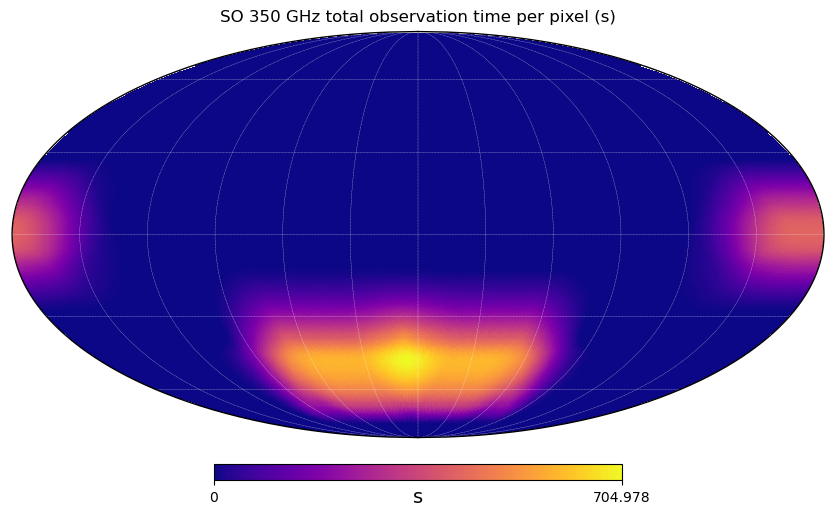

In [4]:
hp.mollview(tobs_per_pix, title='SO 350 GHz total observation time per pixel (s)', unit='s', cmap='plasma')
hp.graticule(lw=0.2, c='w', ls='--')

In [5]:
np.sum(tobs_per_pix) / 60. / 60. / 24. / 365.25

np.float64(6.9999999999999964)

In [6]:
def varpix2uKarcmin(var_map):
    nside_in = hp.get_nside(var_map)
    pixarea_deg = hp.nside2pixarea(nside_in, degrees=True)

    return 60. * np.sqrt(var_map * pixarea_deg) 

In [7]:
NET_telecope = 9.18E+01  # uK*sqrt(s) for SO 350 GHz
obs_efficiency = 0.094605    # 2mm PWV cut * other obs eff factors * detector yield * unmeasured modes

so_350ghz_noise_var = np.zeros_like(so_relhits)
so_350ghz_noise_var[so_bin > 0] = (np.sqrt(2) * NET_telecope)**2. / (tobs_per_pix[so_bin > 0] * obs_efficiency)  # uK-pixel^2 in polarization


In [8]:
so_350ghz_depth_map_uKarcmin = varpix2uKarcmin(so_350ghz_noise_var)

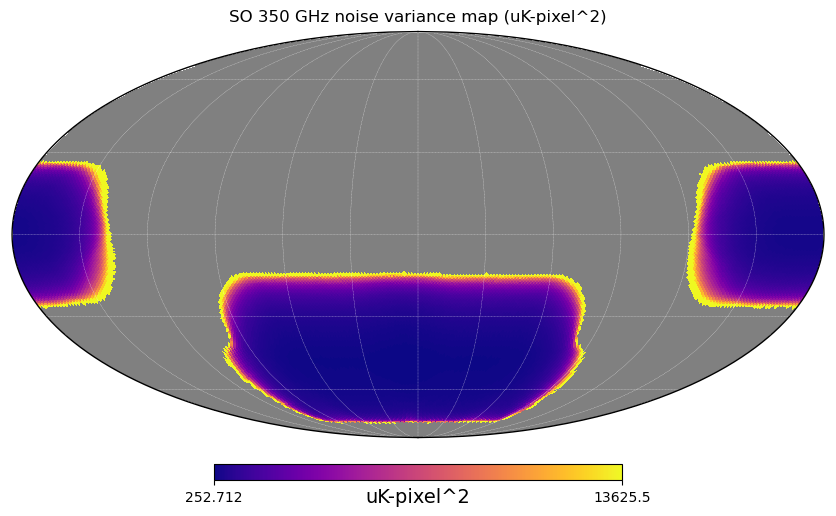

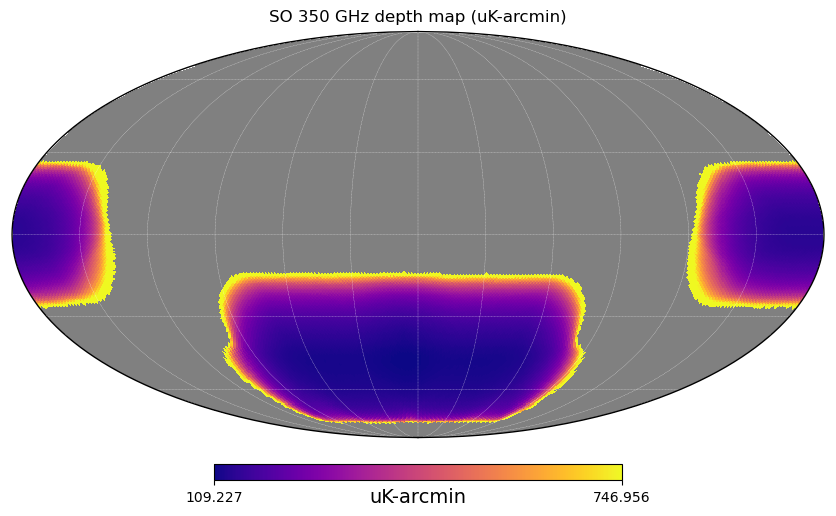

In [9]:
hp.mollview(so_350ghz_noise_var + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz noise variance map (uK-pixel^2)', unit='uK-pixel^2', cmap='plasma', min=np.min(so_350ghz_noise_var[so_bin > 0]), max=np.min(so_350ghz_noise_var[so_bin > 0])+3*np.std(so_350ghz_noise_var[so_bin > 0]))
hp.graticule(lw=0.2, c='w', ls='--')
hp.mollview(so_350ghz_depth_map_uKarcmin + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz depth map (uK-arcmin)', unit='uK-arcmin', cmap='plasma', min=np.min(so_350ghz_depth_map_uKarcmin[so_bin > 0]), max=np.min(so_350ghz_depth_map_uKarcmin[so_bin > 0])+3*np.std(so_350ghz_depth_map_uKarcmin[so_bin > 0]))
hp.graticule(lw=0.2, c='w', ls='--')

In [29]:
uK_arcmin_noise_level = np.mean(so_350ghz_depth_map_uKarcmin[so_relhits == 1.]) # * np.sqrt(2.))  # factor sqrt(2) to convert from P to T equivalent noise
print("SO 350 GHz mean depth over observed area: ", uK_arcmin_noise_level, "uK-arcmin")

SO 350 GHz mean depth over observed area:  109.22724375507654 uK-arcmin


In [11]:
ell_knee_350ghz = 200
alpha_350ghz = 3.

nside = 512
npix = hp.nside2npix(nside)
lmax = 3 * nside - 1

ells = np.arange(lmax+1)
ell_scaling = np.zeros(ells.shape)
ell_scaling[1:] = np.sqrt(1 + (ells[1:] / ell_knee_350ghz)**-alpha_350ghz)

In [12]:
rng = np.random.default_rng(1234)
noise_pix = rng.normal(loc=0.0, scale=1.0, size=(3, npix))

nlm = hp.map2alm(noise_pix, lmax=lmax, pol=True)
for i in range(3):
    nlm[i] = hp.almxfl(nlm[i], ell_scaling)
noise_pix = hp.alm2map(nlm, nside=nside, pol=True) * np.sqrt(so_350ghz_noise_var)
noise_pix[0] /= np.sqrt(2.)  # convert from T to P noise

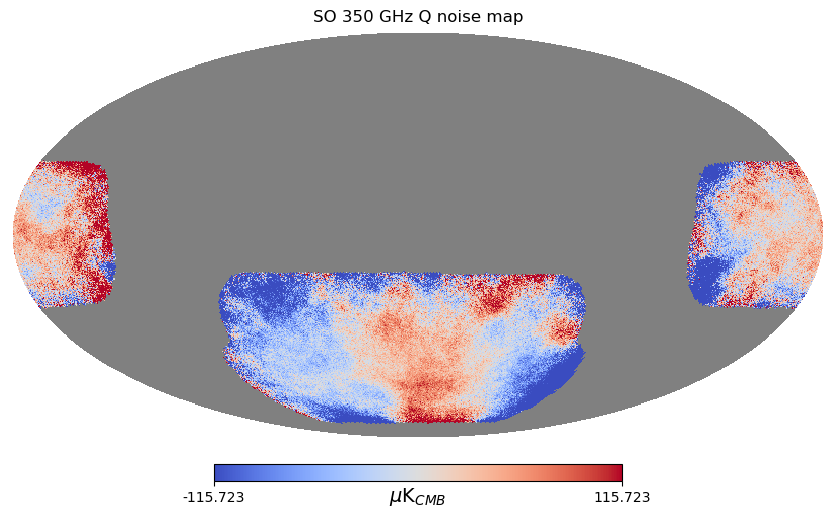

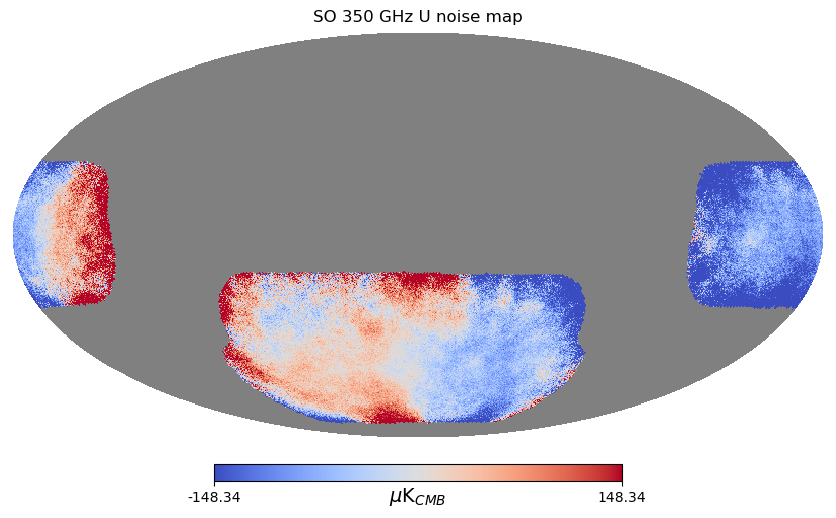

In [13]:
hp.mollview(noise_pix[1] + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz Q noise map', unit=r'$\mu$K${}_{CMB}$', cmap='coolwarm', min=-3*np.std(noise_pix[1][so_relhits > 0.5]), max=3*np.std(noise_pix[1][so_relhits > 0.5]))
hp.mollview(noise_pix[2] + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz U noise map', unit=r'$\mu$K${}_{CMB}$', cmap='coolwarm', min=-3*np.std(noise_pix[2][so_relhits > 0.5]), max=3*np.std(noise_pix[2][so_relhits > 0.5]))

In [14]:
def uKarcmin2Nl(uKarcmin):
    return (uKarcmin * np.deg2rad(1./60.))**2

In [15]:
almsz = hp.Alm.getsize(lmax)
zerom_idx = hp.Alm.getidx(lmax, np.arange(lmax+1, dtype=int), m=0)
Nl = uKarcmin2Nl(uK_arcmin_noise_level) * ell_scaling**2 

hsqrt = np.sqrt(2.) / 2. 
nlm_TEB = np.zeros((3, almsz), dtype=np.complex128)
nlm_TEB[:, zerom_idx] = rng.normal(size=(3,len(zerom_idx)))
nlm_TEB[:, zerom_idx[-1]:] = hsqrt * (rng.normal(size=(3,(almsz - len(zerom_idx)+1))) + 1j*rng.normal(size=(3,(almsz - len(zerom_idx)+1))))

nlm_TEB[0] = hp.almxfl(nlm_TEB[0], np.sqrt(Nl)) / np.sqrt(2)
nlm_TEB[1] = hp.almxfl(nlm_TEB[1], np.sqrt(Nl))
nlm_TEB[2] = hp.almxfl(nlm_TEB[2], np.sqrt(Nl))

hits_scaling = np.zeros(so_relhits.shape)
hits_scaling[so_relhits>=1e-2] = 1. / np.sqrt(so_relhits[so_relhits>=1e-2])
noise_harm = hp.alm2map(nlm_TEB, nside, pol=True) * so_bin * hits_scaling

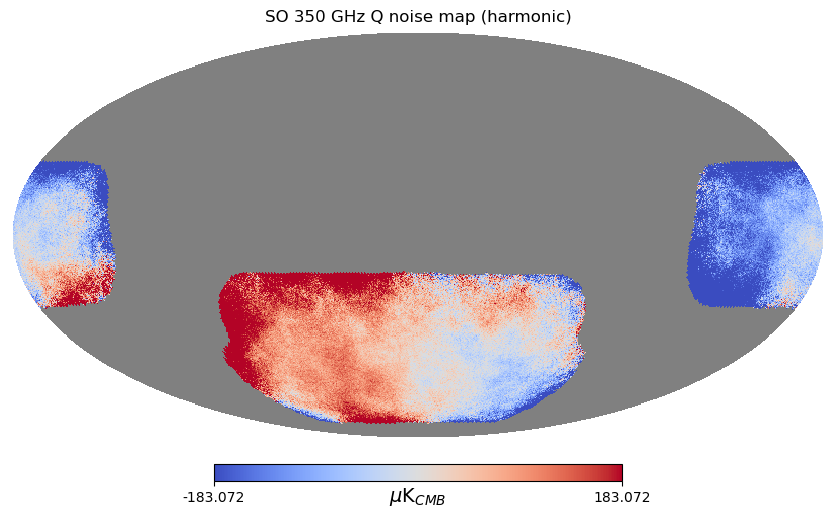

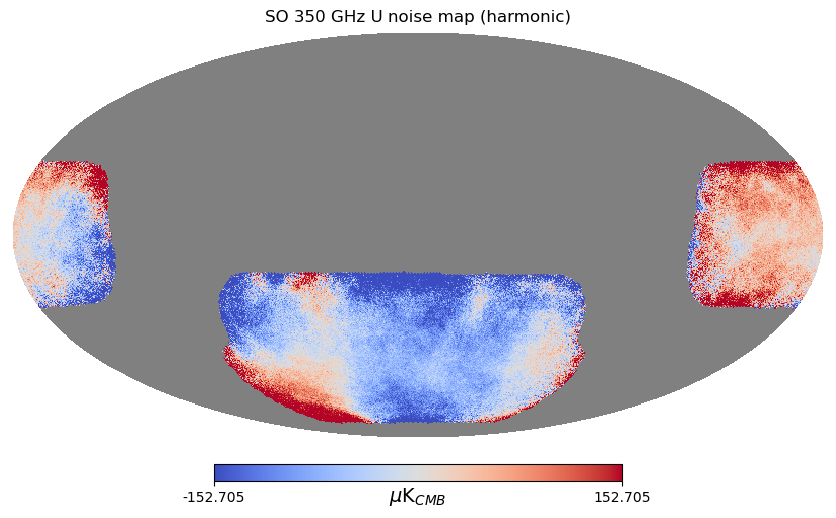

In [16]:
hp.mollview(noise_harm[1] + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz Q noise map (harmonic)', unit=r'$\mu$K${}_{CMB}$', cmap='coolwarm', min=-3*np.std(noise_harm[1][so_relhits > 0.5]), max=3*np.std(noise_harm[1][so_relhits > 0.5]))
hp.mollview(noise_harm[2] + (1-so_bin)*hp.UNSEEN, title='SO 350 GHz U noise map (harmonic)', unit=r'$\mu$K${}_{CMB}$', cmap='coolwarm', min=-3*np.std(noise_harm[2][so_relhits > 0.5]), max=3*np.std(noise_harm[2][so_relhits > 0.5]))

In [17]:
nl_pix = hp.anafast(noise_pix   * so_relhits,   lmax=lmax, pol=True)/st.fsky(so_relhits)
nl_harm = hp.anafast(noise_harm * so_relhits, lmax=lmax, pol=True)/st.fsky(so_relhits)

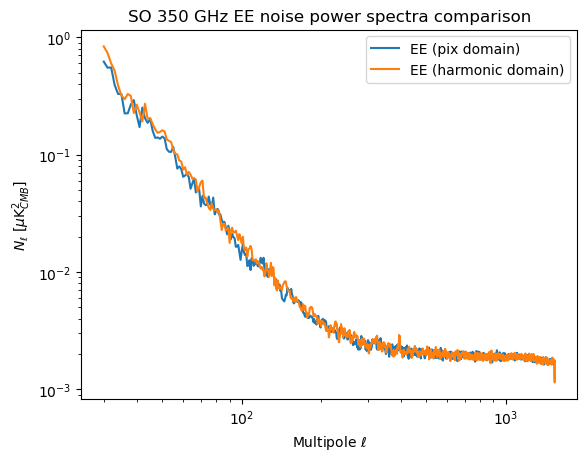

In [18]:
plt.plot(ells[30:], nl_pix [1][30:], '-', c='C0',   label='EE (pix domain)')
plt.plot(ells[30:], nl_harm[1][30:], '-', c='C1', label='EE (harmonic domain)')
plt.loglog()
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$N_\ell$ [$\mu$K${}_{CMB}^2$]')
plt.title('SO 350 GHz EE noise power spectra comparison')
plt.legend()

In [23]:
Nl_white = uKarcmin2Nl(uK_arcmin_noise_level)

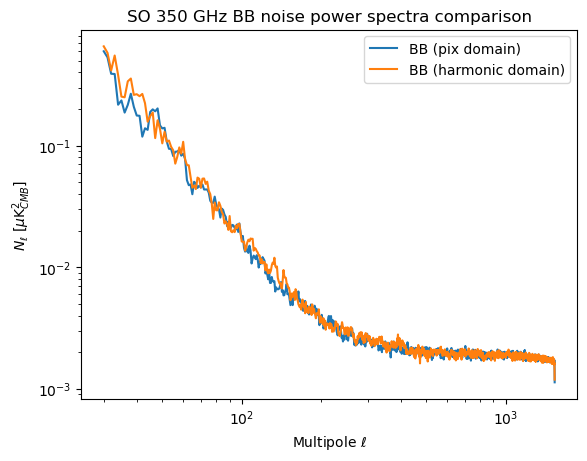

In [26]:
plt.plot(ells[30:], nl_pix [2][30:], '-', c='C0',   label='BB (pix domain)')
plt.plot(ells[30:], nl_harm[2][30:], '-', c='C1', label='BB (harmonic domain)')
plt.loglog()
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$N_\ell$ [$\mu$K${}_{CMB}^2$]')
plt.title('SO 350 GHz BB noise power spectra comparison')
plt.legend()

In [20]:
import scipy.constants as con
wavelength350_mm = con.speed_of_light / (346. * con.giga) * 1.e3  # in mm
print("Wavelength at 346 GHz: ", wavelength350_mm, "mm")

wavelength225_mm = con.speed_of_light / (225. * con.giga) * 1.e3  # in mm
print("Wavelength at 225 GHz: ", wavelength225_mm, "mm")
wavelength280_mm = con.speed_of_light / (280. * con.giga) * 1.e3  # in mm
print("Wavelength at 280 GHz: ", wavelength280_mm, "mm")

Wavelength at 346 GHz:  0.8664521907514451 mm
Wavelength at 225 GHz:  1.3324109244444444 mm
Wavelength at 280 GHz:  1.07068735 mm


In [21]:
theta_225 = 11. 
theta_280 = 9.

gamma = np.log(theta_225 / theta_280) / np.log(wavelength225_mm/ wavelength280_mm)
print("Gamma value for beam scaling: ", gamma)

Gamma value for beam scaling:  0.9176067888895161


In [22]:
theta_346 = theta_280 * (wavelength350_mm / wavelength280_mm)**gamma
print("Projected beam FWHM at 346 GHz: ", theta_346, "arcmin")

Projected beam FWHM at 346 GHz:  7.411359274566185 arcmin
